In [ ]:
import numpy as np
import os
from scipy.spatial.distance import pdist, squareform

# Relocated to src/rarefied/geometry/mesh.py (docs/CLEANUP_TODO.md, Phase 5).
# Function bodies moved verbatim -- see that module for the actual implementations.
from rarefied.geometry.mesh import (
    compute_winding_order,
    convert_mesh_to_sparta,
    ensure_clockwise_order,
    extract_boundary_vertices,
    process_mesh_folder,
    read_mesh_file,
    scale_shape_to_size,
)














##### STEP 1 #######
# Example usage:
# Specify the root folder containing the meshes subfolder
import os as _os
import yaml as _yaml
_registry_entry = _yaml.safe_load(open("../../../data/registry.yaml"))["shape_dataset_2026_02_06_09_28_35"]
assert _registry_entry["status"] == "verified", _registry_entry["status"]
mesh_root_folder = _os.path.expanduser(_registry_entry["local_path"])
process_mesh_folder(mesh_root_folder, target_size=0.3)
#####################

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Relocated to src/rarefied/geometry/sparta_shapes.py and
# src/rarefied/geometry/plotting.py (docs/CLEANUP_TODO.md, Phase 5).
# Function bodies moved verbatim -- see those modules for the actual implementations.
from rarefied.geometry.sparta_shapes import read_sparta_file
from rarefied.geometry.plotting import plot_shape




# Plot first and last shapes
def plot_mesh_shapes(sparta_folder, target_size=None):
    """Plot the first and last shapes from the SPARTA folder for debugging."""
    # Get all SPARTA files
    sparta_files = sorted([f for f in os.listdir(sparta_folder) if f.endswith('.txt')])
    
    if not sparta_files:
        print(f"No SPARTA files found in {sparta_folder}")
        return
    
    first_file = sparta_files[0]
    last_file = sparta_files[1]
    
    # Read files
    first_path = os.path.join(sparta_folder, first_file)
    last_path = os.path.join(sparta_folder, last_file)
    
    points_first, lines_first = read_sparta_file(first_path)
    points_last, lines_last = read_sparta_file(last_path)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    plot_shape(points_first, lines_first, f"First Shape: {first_file}", ax=ax1, target_size=target_size)
    plot_shape(points_last, lines_last, f"Last Shape: {last_file}", ax=ax2, target_size=target_size)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nFirst shape: {first_file} ({len(points_first)} vertices, {len(lines_first)} edges)")
    print(f"Last shape: {last_file} ({len(points_last)} vertices, {len(lines_last)} edges)")
    if target_size is not None:
        print(f"Target size (max pairwise distance): {target_size:.6f}")


##### STEP 2 #######
# Example usage - plot shapes from the SPARTA converted folder
import yaml as _yaml
_registry_entry = _yaml.safe_load(open("../../../data/registry.yaml"))["shape_dataset_2026_02_06_09_28_35"]
assert _registry_entry["status"] == "verified", _registry_entry["status"]
sparta_folder = os.path.join(os.path.expanduser(_registry_entry["local_path"]), "sparta_converted")
target_size = 0.3  # Match the target_size used in conversion
if os.path.exists(sparta_folder):
    plot_mesh_shapes(sparta_folder, target_size=target_size)
else:
    print(f"SPARTA folder not found at: {sparta_folder}")
######################

In [ ]:
from matplotlib.path import Path
from matplotlib.colors import ListedColormap

# Relocated to src/rarefied/geometry/regions.py (docs/CLEANUP_TODO.md, Phase 5).
# Function bodies moved verbatim -- see that module for the actual implementations.
from rarefied.geometry.regions import (
    compute_region_circle_union,
    compute_region_properties,
    divide_vertices_into_regions,
    estimate_circle_union_area,
    process_sparta_folder,
)






# Relocated to src/rarefied/geometry/plotting.py (docs/CLEANUP_TODO.md, Phase 5).
# Function bodies moved verbatim -- see that module for the actual implementations.
from rarefied.geometry.plotting import draw_circle_arc, shade_circle_union_area






# ####### STEP 3 #######

# # Example usage - process SPARTA files and create region metadata
# sparta_folder = "shapes/dataset_2026-02-06_09_28_35/sparta_converted"
# if os.path.exists(sparta_folder):
#     process_sparta_folder(sparta_folder, max_regions=30, min_points_per_region=4, integration_samples=250)
# else:
#     print(f"SPARTA folder not found at: {sparta_folder}")

# #######################
# Relocated to src/rarefied/geometry/regions.py (docs/CLEANUP_TODO.md, Phase 5).
# Function body moved verbatim -- see that module for the actual implementation.
from rarefied.geometry.regions import read_region_metadata




# Relocated to src/rarefied/geometry/plotting.py (docs/CLEANUP_TODO.md, Phase 5).
# Function body moved verbatim -- see that module for the actual implementation.
from rarefied.geometry.plotting import plot_regions_for_shape


def plot_regions_comparison(sparta_folder, region_metadata_folder=None, show_bbox=True, 
                            show_fitted_circle=True, show_circles=True, show_normal=True, show_tangent=False,
                            show_area_shading=False, area_plot_samples=80, plot_every_n_regions=1):
    """
    Plot the first and last shapes with their circle union regions.
    """
    if region_metadata_folder is None:
        region_metadata_folder = os.path.join(sparta_folder, 'region_metadata')
    
    sparta_files = sorted([f for f in os.listdir(sparta_folder) 
                          if f.endswith('.txt') and '_metadata' not in f])
    
    if len(sparta_files) < 2:
        print(f"Need at least 2 SPARTA files to plot comparison")
        return
    
    metadata_files = sorted([f for f in os.listdir(region_metadata_folder) 
                           if f.endswith('_region_metadata.txt')])
    
    metadata_map = {}
    for metadata_file in metadata_files:
        base_name = metadata_file.replace('_region_metadata.txt', '')
        metadata_map[base_name] = metadata_file
    
    first_sparta_file = sparta_files[0]
    last_sparta_file = sparta_files[-1]
    
    first_base_name = os.path.splitext(first_sparta_file)[0]
    last_base_name = os.path.splitext(last_sparta_file)[0]
    
    first_metadata_file = metadata_map.get(first_base_name)
    last_metadata_file = metadata_map.get(last_base_name)
    
    if first_metadata_file is None or last_metadata_file is None:
        print(f"Error: Could not find matching metadata files")
        return
    
    first_sparta_path = os.path.join(sparta_folder, first_sparta_file)
    first_metadata_path = os.path.join(region_metadata_folder, first_metadata_file)
    
    first_points, first_lines = read_sparta_file(first_sparta_path)
    first_regions = read_region_metadata(first_metadata_path)
    
    last_sparta_path = os.path.join(sparta_folder, last_sparta_file)
    last_metadata_path = os.path.join(region_metadata_folder, last_metadata_file)
    
    last_points, last_lines = read_sparta_file(last_sparta_path)
    last_regions = read_region_metadata(last_metadata_path)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    plot_regions_for_shape((first_points, first_lines), first_regions,
                          f"First Shape: {first_sparta_file} ({len(first_regions)} regions)", ax=ax1,
                          show_bbox=show_bbox, show_fitted_circle=show_fitted_circle, show_circles=show_circles,
                          show_normal=show_normal, show_tangent=show_tangent,
                          show_area_shading=show_area_shading, area_plot_samples=area_plot_samples,
                          plot_every_n_regions=plot_every_n_regions)
    plot_regions_for_shape((last_points, last_lines), last_regions,
                          f"Last Shape: {last_sparta_file} ({len(last_regions)} regions)", ax=ax2,
                          show_bbox=show_bbox, show_fitted_circle=show_fitted_circle, show_circles=show_circles,
                          show_normal=show_normal, show_tangent=show_tangent,
                          show_area_shading=show_area_shading, area_plot_samples=area_plot_samples,
                          plot_every_n_regions=plot_every_n_regions)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nFirst shape: {first_sparta_file}")
    print(f"  Vertices: {len(first_points)}")
    print(f"  Regions: {len(first_regions)}")
    for region in first_regions:
        min_x, max_x, min_y, max_y = region['bbox']
        fitted_circle = region.get('fitted_circle')
        aoa = region.get('aoa')
        union_area = region.get('union_area')
        collection_area = region.get('collection_area')
        num_circles = len(region.get('circles', []))
        tangent = region.get('tangent')
        tangent_info = f", Tangent: ({tangent[0]:.4f}, {tangent[1]:.4f})" if tangent is not None else ""
        fitted_info = ""
        if fitted_circle:
            r = fitted_circle['radius']
            curvature = 1.0 / r if r != 0 else float('inf')
            fitted_info = f", Fitted: r={r:.6f}, κ={curvature:.6f}"
        aoa_info = f", AoA={aoa:.4f} rad" if aoa is not None else ""
        area_info = f", Aunion={union_area:.6e}, Acollect={collection_area:.6e}" if union_area is not None else ""
        print(f"    Region {region['index']}: {region['num_points']} pts, {num_circles} circles, " + 
              f"Normal: ({region['normal'][0]:.4f}, {region['normal'][1]:.4f}){tangent_info}{fitted_info}{aoa_info}{area_info}")
    
    print(f"\nLast shape: {last_sparta_file}")
    print(f"  Vertices: {len(last_points)}")
    print(f"  Regions: {len(last_regions)}")
    for region in last_regions:
        min_x, max_x, min_y, max_y = region['bbox']
        fitted_circle = region.get('fitted_circle')
        aoa = region.get('aoa')
        union_area = region.get('union_area')
        collection_area = region.get('collection_area')
        num_circles = len(region.get('circles', []))
        tangent = region.get('tangent')
        tangent_info = f", Tangent: ({tangent[0]:.4f}, {tangent[1]:.4f})" if tangent is not None else ""
        fitted_info = ""
        if fitted_circle:
            r = fitted_circle['radius']
            curvature = 1.0 / r if r != 0 else float('inf')
            fitted_info = f", Fitted: r={r:.6f}, κ={curvature:.6f}"
        aoa_info = f", AoA={aoa:.4f} rad" if aoa is not None else ""
        area_info = f", Aunion={union_area:.6e}, Acollect={collection_area:.6e}" if union_area is not None else ""
        print(f"    Region {region['index']}: {region['num_points']} pts, {num_circles} circles, " + 
              f"Normal: ({region['normal'][0]:.4f}, {region['normal'][1]:.4f}){tangent_info}{fitted_info}{aoa_info}{area_info}")

# Example usage - plot regions comparison with different visualization options

####### STEP 4 #######
# Option 1: Show both bounding boxes and circle unions (default)
import yaml as _yaml
_registry_entry = _yaml.safe_load(open("../../../data/registry.yaml"))["shape_dataset_2026_02_06_09_28_35"]
assert _registry_entry["status"] == "verified", _registry_entry["status"]
sparta_folder = os.path.join(os.path.expanduser(_registry_entry["local_path"]), "sparta_converted")
region_metadata_folder = os.path.join(sparta_folder, 'region_metadata')
plot_every_n_regions = 4  # Increase to 3, 4, ... for less clutter
if os.path.exists(region_metadata_folder):
    print("=== Visualization: Circle Unions ===")
    plot_regions_comparison(sparta_folder, region_metadata_folder, 
                           show_bbox=True, show_fitted_circle=True, show_circles=True,
                           show_normal=True, show_tangent=False,
                           show_area_shading=False, area_plot_samples=100,
                           plot_every_n_regions=plot_every_n_regions)
else:
    print(f"Region metadata folder not found at: {region_metadata_folder}")

#########################

# Option 2: Show area shading for validation
plot_regions_comparison(sparta_folder, region_metadata_folder, 
                       show_bbox=True, show_fitted_circle=True, show_circles=True,
                       show_normal=True, show_tangent=True,
                       show_area_shading=True, area_plot_samples=120,
                       plot_every_n_regions=plot_every_n_regions)

# Option 3: Show only circle unions
# plot_regions_comparison(sparta_folder, region_metadata_folder, 
#                        show_bbox=False, show_fitted_circle=False, show_circles=True,
#                        show_normal=True, show_tangent=False,
#                        show_area_shading=False)


In [ ]:
# Relocated to src/rarefied/geometry/circle.py (docs/CLEANUP_TODO.md, Phase 5).
# Function body moved verbatim -- see that module for the actual implementation.
from rarefied.geometry.circle import generate_circle_shape



# Example usage:
# Generate a circle with 1 ft diameter (0.3048 m), 150 points, and full processing
circle_result = generate_circle_shape(diameter=0.3048, num_points=300, 
                                     output_sparta_path='argon_circle.txt',
                                     process_regions=True, max_regions=10,
                                     visualize=True, show_bbox=True, show_fitted_circle=True,
                                     show_circles=True, show_normal=True, show_tangent=True,
                                     show_area_shading=True, area_plot_samples=100, integration_samples=250)

print(f"\nCircle generation complete!")
print(f"  SPARTA file: {circle_result['sparta_path']}")
if 'metadata_path' in circle_result:
    print(f"  Metadata file: {circle_result['metadata_path']}")
    print(f"  Regions: {len(circle_result['regions'])}")
    for region in circle_result['regions']:
        num_circles = len(region.get('circles', []))
        print(f"    Region {region['index']}: {region['num_points']} points, {num_circles} circles")


In [ ]:
# Demonstration of different visualization options for regions

print("\n" + "="*80)
print("CIRCLE FITTING VISUALIZATION DEMONSTRATION")
print("="*80)

import os
import yaml as _yaml
_registry_entry = _yaml.safe_load(open("../../../data/registry.yaml"))["shape_dataset_2026_02_06_09_28_35"]
assert _registry_entry["status"] == "verified", _registry_entry["status"]
sparta_folder = os.path.join(os.path.expanduser(_registry_entry["local_path"]), "sparta_converted")
region_metadata_folder = os.path.join(sparta_folder, 'region_metadata')

print("\n--- Option 1: Show ONLY Fitted Circles (no bounding boxes) ---")
print("This is useful for examining circle fits in isolation")
plot_regions_comparison(sparta_folder, region_metadata_folder, 
                       show_bbox=False, show_circle=True, show_normal=False)

print("\n--- Option 2: Show ONLY Bounding Boxes (no circles) ---")
print("This is useful for examining bounding box coverage")
plot_regions_comparison(sparta_folder, region_metadata_folder, 
                       show_bbox=True, show_circle=False, show_normal=False)

print("\n--- Option 3: Show All (circles, boxes, and normals) ---")
print("This is the comprehensive view with all geometric data")
plot_regions_comparison(sparta_folder, region_metadata_folder, 
                       show_bbox=True, show_circle=True, show_normal=True)


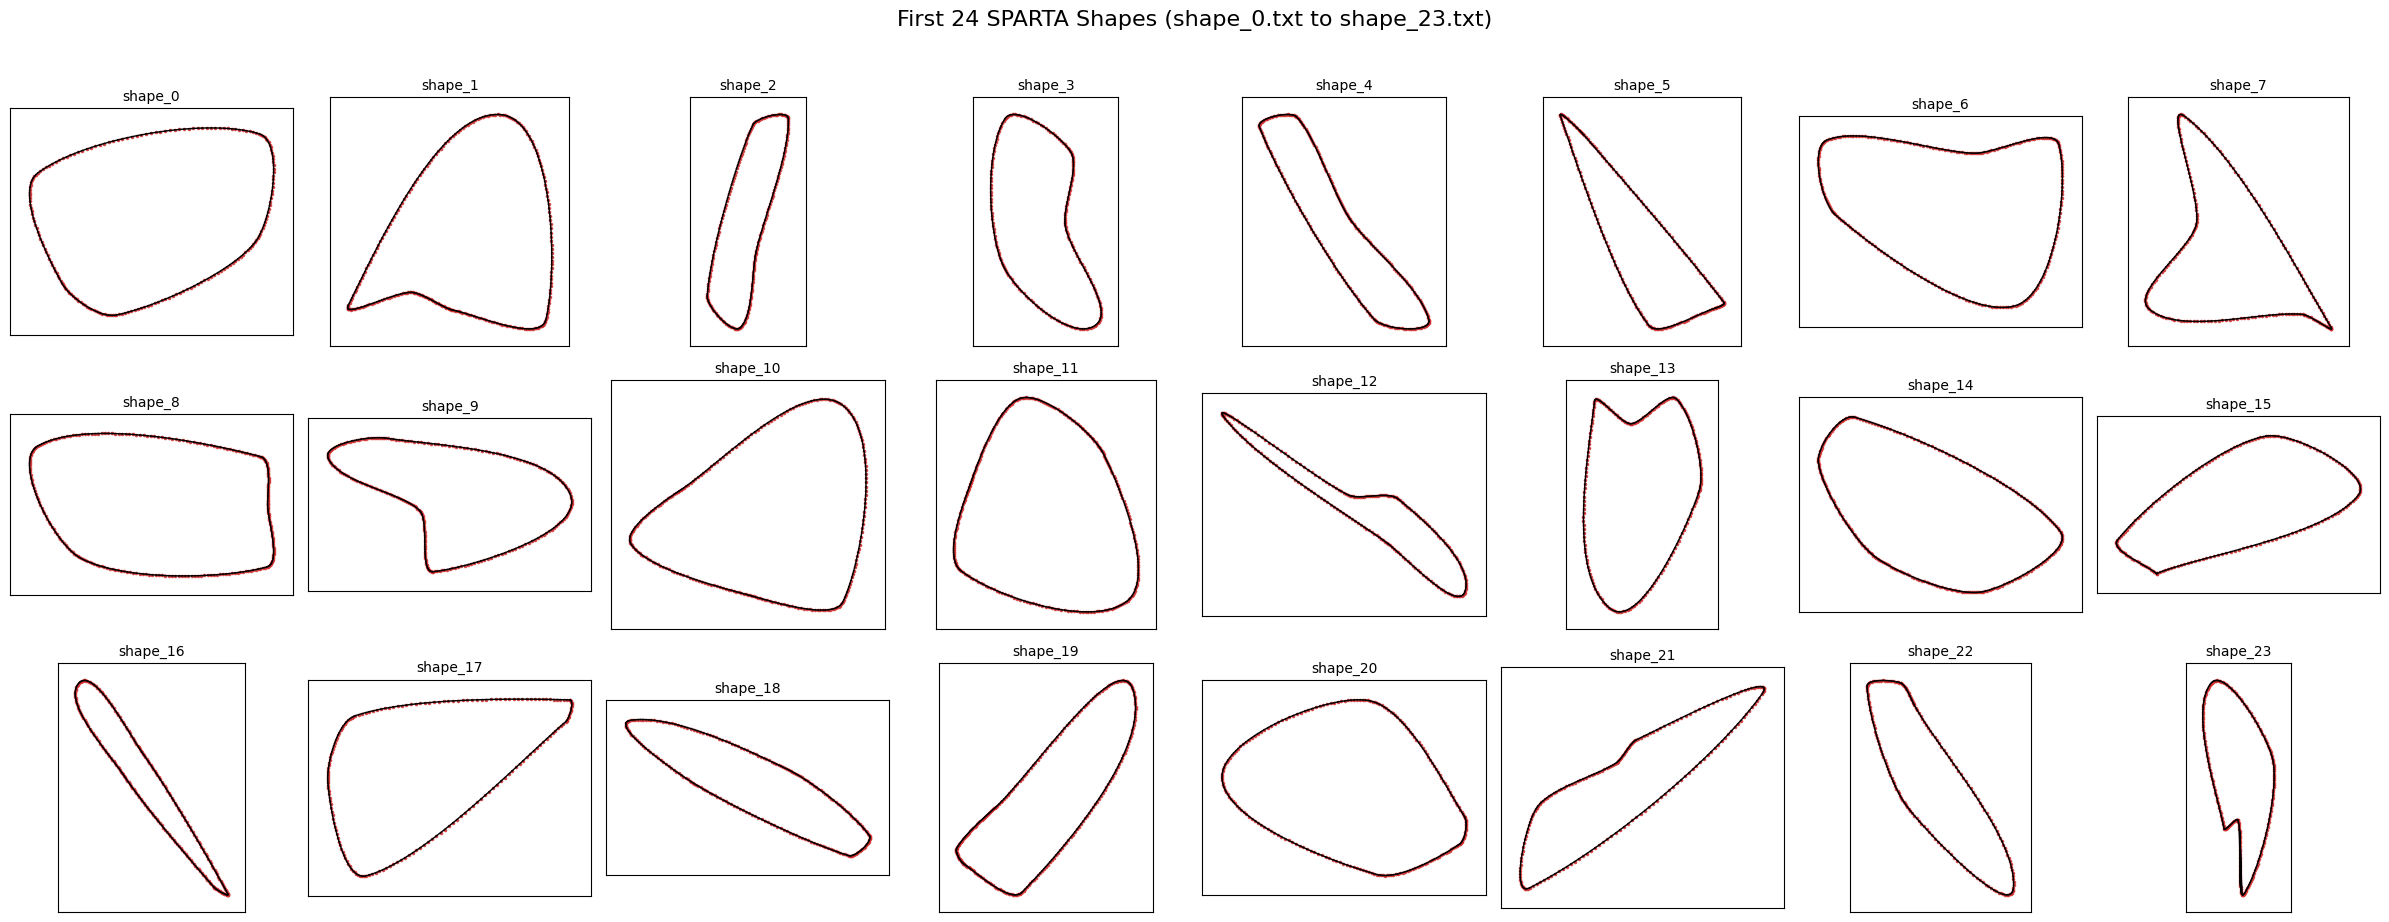

Saved image to: /Users/kofiblake/Documents/Meteor_Modelling/code/shapes/dataset_2026-02-06_09_28_35/first_24_shapes_grid.png
Done. Grid figure saved at: shapes/dataset_2026-02-06_09_28_35/first_24_shapes_grid.png


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt


def _read_sparta_points_lines(filepath):
    """Read a SPARTA file and return points + line segments."""
    points = {}
    line_segments = []

    with open(filepath, "r") as f:
        raw_lines = [line.strip() for line in f.readlines()]

    in_points = False
    in_lines = False

    for line in raw_lines:
        if not line:
            continue

        if line == "Points":
            in_points = True
            in_lines = False
            continue
        if line == "Lines":
            in_points = False
            in_lines = True
            continue

        if in_points:
            parts = line.split()
            if len(parts) >= 3:
                idx = int(parts[0])
                points[idx] = (float(parts[1]), float(parts[2]))
        elif in_lines:
            parts = line.split()
            if len(parts) >= 3:
                p1 = int(parts[1])
                p2 = int(parts[2])
                if p1 in points and p2 in points:
                    line_segments.append((points[p1], points[p2]))

    return points, line_segments


def plot_first_24_shapes_grid(root_folder, save_name="first_24_shapes_grid.png", dpi=300):
    """
    Plot shape_0.txt through shape_23.txt from <root_folder>/sparta_converted
    into a 3x8 grid, then save the image.
    """
    sparta_folder = os.path.join(root_folder, "sparta_converted")
    if not os.path.isdir(sparta_folder):
        raise FileNotFoundError(
            f"Could not find 'sparta_converted' inside: {os.path.abspath(root_folder)}"
        )

    fig, axes = plt.subplots(3, 8, figsize=(24, 9))
    axes = axes.ravel()

    for i in range(24):
        ax = axes[i]
        file_name = f"shape_{i}.txt"
        file_path = os.path.join(sparta_folder, file_name)

        if not os.path.isfile(file_path):
            ax.text(0.5, 0.5, f"Missing\n{file_name}", ha="center", va="center", fontsize=10)
            ax.set_title(f"shape_{i}", fontsize=10)
            ax.set_aspect("equal", adjustable="box")
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        if "read_sparta_file" in globals():
            points, line_segments = read_sparta_file(file_path)
        else:
            points, line_segments = _read_sparta_points_lines(file_path)

        for p1, p2 in line_segments:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="black", linewidth=1.0)

        if points:
            verts = np.array(list(points.values()))
            ax.scatter(verts[:, 0], verts[:, 1], s=2.5, color="#d32f2f", alpha=0.8)

            x_min, x_max = np.min(verts[:, 0]), np.max(verts[:, 0])
            y_min, y_max = np.min(verts[:, 1]), np.max(verts[:, 1])
            span = max(x_max - x_min, y_max - y_min, 1e-12)
            pad = 0.08 * span
            ax.set_xlim(x_min - pad, x_max + pad)
            ax.set_ylim(y_min - pad, y_max + pad)

        ax.set_title(f"shape_{i}", fontsize=10)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle("First 24 SPARTA Shapes (shape_0.txt to shape_23.txt)", fontsize=16, y=1.02)
    plt.tight_layout()

    save_path = os.path.join(root_folder, save_name)
    fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved image to: {os.path.abspath(save_path)}")
    return save_path


# Input the parent folder that contains "sparta_converted"
root_folder = input("Enter folder path (contains 'sparta_converted'): ").strip()
if not root_folder:
    root_folder = "."

saved_path = plot_first_24_shapes_grid(root_folder)
print(f"Done. Grid figure saved at: {saved_path}")